# Summarize

TODO: 
- We have strongly supposed that the '_' values where just zeros, that was a strong assupmtuion and we must treat them as null values
- There are plenty resource and methods to handle missing values, here we are applying just something similar to 'Last observation carried forward'
- The reason why is that we have indentified in these features () that the value does not change over the months, but it would be interesing to test how model changes with different approahces of handling misisng values

# Libraries

In [1]:
import os

os.chdir("..")

import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter

from src.data_cleaning import (
    cleaning_int_variables,
    clean_credit_history,
    clean_type_of_loan,
    fill_credit_age,
)

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

# Data

In [2]:
train_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS, "parisrohan/credit-score-classification", "train.csv"
)

/var/folders/1f/54wv342x795c_zyzqlgyjjkw0000gn/T/ipykernel_10425/4040410273.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  train_df = kagglehub.load_dataset(
/Users/luisfernandocorcueraleon/Desktop/code/Credit-Score-Classification/.venv/lib/python3.14/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (0: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [3]:
month_mapping = {
    "January": 202201,
    "February": 202202,
    "March": 202203,
    "April": 202204,
    "May": 202205,
    "June": 202206,
    "July": 202207,
    "August": 202208,
}

train_df["num_month"] = train_df["Month"].map(month_mapping)

train_df["num_month"].value_counts()

num_month
202201    12500
202202    12500
202203    12500
202204    12500
202205    12500
202206    12500
202207    12500
202208    12500
Name: count, dtype: int64

# Cleaning Numerical Values:

In [4]:
train_df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score', 'num_month'],
      dtype='str')

There are many similar cases of numerical values that are object type and have '_' values to clean

In [5]:
train_df["Age"] = cleaning_int_variables(train_df["Age"], "_", "", int)
train_df["Annual_Income"] = cleaning_int_variables(
    train_df["Annual_Income"], "_", "", float
)
train_df["Num_of_Loan"] = cleaning_int_variables(train_df["Num_of_Loan"], "_", "", int)
train_df["Changed_Credit_Limit"] = cleaning_int_variables(
    train_df["Changed_Credit_Limit"], "_", "0", float
)
train_df["Outstanding_Debt"] = cleaning_int_variables(
    train_df["Outstanding_Debt"], "_", "", float
)
train_df["Amount_invested_monthly"] = cleaning_int_variables(
    train_df["Amount_invested_monthly"], "_", "", float
)
train_df["Monthly_Balance"] = cleaning_int_variables(
    train_df["Monthly_Balance"], "_", "", float
)
train_df["Num_of_Delayed_Payment"] = cleaning_int_variables(
    train_df["Num_of_Delayed_Payment"], "_", "", float
)

In [6]:
train_df["Credit_History_Age"] = train_df["Credit_History_Age"].apply(
    clean_credit_history
)
train_df["Credit_History_Age"].describe()

count   90,970.00
mean        18.43
std          8.31
min          0.08
25%         12.00
50%         18.25
75%         25.17
max         33.67
Name: Credit_History_Age, dtype: float64

In [7]:
numeric_df = train_df.select_dtypes(include="number")
numeric_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  int64  
 1   Annual_Income             100000 non-null  float64
 2   Monthly_Inhand_Salary     84998 non-null   float64
 3   Num_Bank_Accounts         100000 non-null  int64  
 4   Num_Credit_Card           100000 non-null  int64  
 5   Interest_Rate             100000 non-null  int64  
 6   Num_of_Loan               100000 non-null  int64  
 7   Delay_from_due_date       100000 non-null  int64  
 8   Num_of_Delayed_Payment    92998 non-null   float64
 9   Changed_Credit_Limit      100000 non-null  float64
 10  Num_Credit_Inquiries      98035 non-null   float64
 11  Outstanding_Debt          100000 non-null  float64
 12  Credit_Utilization_Ratio  100000 non-null  float64
 13  Credit_History_Age        90970 non-null   float64
 14  

In [8]:
numeric_df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,num_month
count,"100,000.00","100,000.00","84,998.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","92,998.00","100,000.00","98,035.00","100,000.00","100,000.00","90,970.00","100,000.00","95,521.00","97,132.00","100,000.00"
mean,110.65,"176,415.70","4,194.17",17.09,22.47,72.47,3.01,21.07,30.92,10.17,27.75,"1,426.22",32.29,18.43,"1,403.12",637.41,"-30,885,804,884,075,277,713,408.00","202,204.50"
std,686.24,"1,429,618.05","3,183.69",117.40,129.06,466.42,62.65,14.86,226.03,6.88,193.18,"1,155.13",5.12,8.31,"8,306.04","2,043.32","3,208,491,911,407,571,723,878,400.00",2.29
min,-500.00,"7,005.93",303.65,-1.00,0.00,1.00,-100.00,-5.00,-3.00,-6.49,0.00,0.23,20.00,0.08,0.00,0.00,"-333,333,333,333,333,314,856,026,112.00","202,201.00"
25%,24.00,"19,457.50","1,625.57",3.00,4.00,8.00,1.00,10.00,9.00,4.97,3.00,566.07,28.05,12.00,30.31,74.53,269.99,"202,202.75"
50%,33.00,"37,578.61","3,093.75",6.00,5.00,13.00,3.00,18.00,14.00,9.25,6.00,"1,166.15",32.31,18.25,69.25,135.93,336.45,"202,204.50"
75%,42.00,"72,790.92","5,957.45",7.00,7.00,20.00,5.00,28.00,18.00,14.66,9.00,"1,945.96",36.50,25.17,161.22,265.73,469.64,"202,206.25"
max,"8,698.00","24,198,062.00","15,204.63","1,798.00","1,499.00","5,797.00","1,496.00",67.00,"4,397.00",36.97,"2,597.00","4,998.07",50.00,33.67,"82,331.00","10,000.00","1,602.04","202,208.00"


# Cleaning Categorical values

In [9]:
categorical_variables = [
    "Occupation",
    "Type_of_Loan",
    "Credit_Mix",
    "Payment_Behaviour",
    "Payment_of_Min_Amount",
]

## Payment Behaviour

In [10]:
train_df["Payment_Behaviour"].value_counts()

Payment_Behaviour
Low_spent_Small_value_payments      25513
High_spent_Medium_value_payments    17540
Low_spent_Medium_value_payments     13861
High_spent_Large_value_payments     13721
High_spent_Small_value_payments     11340
Low_spent_Large_value_payments      10425
!@9#%8                               7600
Name: count, dtype: int64

In [11]:
train_df[train_df["Payment_Behaviour"] == "!@9#%8"].head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,num_month
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,"19,114.12",NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",8,4.00,9.27,4.00,Good,809.98,27.26,22.50,No,49.57,62.43,!@9#%8,340.48,Good,202206
16,0x161a,CUS_0x2dbc,January,Langep,34,486-85-3974,_______,"143,162.64","12,187.22",1,5,8,3,"Auto Loan, Auto Loan, and Not Specified",5,8.00,7.10,3.00,Good,"1,303.01",28.62,17.75,No,246.99,168.41,!@9#%8,"1,043.32",Good,202201
32,0x1632,CUS_0x1cdb,January,Deepaa,21,615-06-7821,Developer,"35,547.71","2,853.31",7,5,5,0,NaN,5,NaN,2.58,4.00,Standard,943.86,39.80,30.67,Yes,0.00,276.73,!@9#%8,288.61,Standard,202201
47,0x1645,CUS_0x95ee,August,Np,31,612-70-8987,Lawyer,"73,928.46","5,988.71",4,5,8,0,NaN,8,7.00,10.14,NaN,Good,548.20,31.58,32.50,No,0.00,42.64,!@9#%8,796.23,Good,202208
54,0x1650,CUS_0x284a,July,Nadiaq,34,#F%$D@*&8,Lawyer,"10,909,427.00",NaN,0,1,8,2,"Credit-Builder Loan, and Mortgage Loan",0,2.00,9.34,4.00,Good,352.16,26.95,31.08,No,911.22,930.39,!@9#%8,326.24,Good,202207


In [12]:
train_df[train_df["Customer_ID"] == "CUS_0xd40"]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,num_month
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,"19,114.12","1,824.84",3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.00,11.27,4.00,_,809.98,26.82,22.08,No,49.57,80.42,High_spent_Small_value_payments,312.49,Good,202201
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,"19,114.12",NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.00,Good,809.98,31.94,NaN,No,49.57,118.28,Low_spent_Large_value_payments,284.63,Good,202202
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,"19,114.12",NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.00,0.00,4.00,Good,809.98,28.61,22.25,No,49.57,81.70,Low_spent_Medium_value_payments,331.21,Good,202203
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,"19,114.12",NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4.00,6.27,4.00,Good,809.98,31.38,22.33,No,49.57,199.46,Low_spent_Small_value_payments,223.45,Good,202204
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,"19,114.12","1,824.84",3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.00,Good,809.98,24.80,22.42,No,49.57,41.42,High_spent_Medium_value_payments,341.49,Good,202205
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,"19,114.12",NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",8,4.00,9.27,4.00,Good,809.98,27.26,22.50,No,49.57,62.43,!@9#%8,340.48,Good,202206
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,"19,114.12","1,824.84",3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,8.00,11.27,4.00,Good,809.98,22.54,22.58,No,49.57,178.34,Low_spent_Small_value_payments,244.57,Good,202207
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,"19,114.12","1,824.84",3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,6.00,11.27,4.00,Good,809.98,23.93,NaN,No,49.57,24.79,High_spent_Medium_value_payments,358.12,Standard,202208


In [13]:
train_df["Payment_Behaviour"] = train_df["Payment_Behaviour"].replace("!@9#%8", pd.NA)

In [14]:
print(train_df["Payment_Behaviour"].isnull().sum())
print(
    train_df.groupby("Customer_ID")["Payment_Behaviour"]
    .apply(lambda x: x.isnull().sum())
    .value_counts()
)

7600
Payment_Behaviour
0    6600
1    4459
2    1210
3     205
4      24
5       2
Name: count, dtype: int64


## Occupation

In [15]:
train_df[train_df["Occupation"] == "_______"].head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,num_month
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28,004-07-5839,_______,"34,847.84","3,037.99",2,4,6,1,Credit-Builder Loan,3,4.00,5.42,2.00,Good,605.03,24.46,26.58,No,18.82,104.29,Low_spent_Small_value_payments,470.69,Standard,202201
16,0x161a,CUS_0x2dbc,January,Langep,34,486-85-3974,_______,"143,162.64","12,187.22",1,5,8,3,"Auto Loan, Auto Loan, and Not Specified",5,8.00,7.10,3.00,Good,"1,303.01",28.62,17.75,No,246.99,168.41,NaN,"1,043.32",Good,202201
18,0x161c,CUS_0x2dbc,March,Langep,34,486-85-3974,_______,"143,162.64",NaN,1,5,8,3,"Auto Loan, Auto Loan, and Not Specified",8,7.00,11.10,NaN,Good,"1,303.01",26.52,17.92,No,246.99,"10,000.00",High_spent_Small_value_payments,715.74,Good,202203
20,0x161e,CUS_0x2dbc,May,Langep,34,486-85-3974,_______,"143,162.64","12,187.22",1,5,8,3,"Auto Loan, Auto Loan, and Not Specified",10,5.00,7.10,3.00,Good,"1,303.01",31.38,18.08,No,246.99,430.95,Low_spent_Large_value_payments,810.78,Good,202205
29,0x162b,CUS_0xb891,June,Jasond,55,#F%$D@*&8,_______,"30,689.89","2,612.49",2,5,4,1,Not Specified,5,6.00,-3.01,4.00,_,632.46,27.45,17.67,No,16.42,84.95,High_spent_Small_value_payments,419.88,Standard,202206


In [16]:
train_df[train_df["Customer_ID"] == "CUS_0x9e67"].head(10)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,num_month
93280,0x23892,CUS_0x9e67,January,Marias,24,366-87-4584,_______,"44,393.86","3,504.49",6,3,12,2,"Student Loan, and Payday Loan",11,9.00,10.74,NaN,_,"1,270.97",37.33,NaN,Yes,63.79,91.47,High_spent_Medium_value_payments,445.18,Standard,202201
93281,0x23893,CUS_0x9e67,February,NaN,24,366-87-4584,Media_Manager,"44,393.86",NaN,6,3,12,2,"Student Loan, and Payday Loan",15,11.00,10.74,3.00,Standard,"1,270.97",38.29,20.33,Yes,63.79,48.74,High_spent_Large_value_payments,477.91,Standard,202202
93282,0x23894,CUS_0x9e67,March,Marias,24,366-87-4584,_______,"44,393.86","3,504.49",6,3,12,2,"Student Loan, and Payday Loan",15,11.00,10.74,3.00,_,"1,270.97",29.12,20.42,Yes,63.79,73.10,High_spent_Medium_value_payments,463.55,Standard,202203
93283,0x23895,CUS_0x9e67,April,Marias,24,366-87-4584,_______,"44,393.86","3,504.49",6,3,12,2,"Student Loan, and Payday Loan",15,13.00,0.00,3.00,_,"1,270.97",27.48,NaN,Yes,63.79,218.85,Low_spent_Small_value_payments,357.81,Standard,202204
93284,0x23896,CUS_0x9e67,May,NaN,24,366-87-4584,_______,"44,393.86","3,504.49",6,3,12,2,"Student Loan, and Payday Loan",19,11.00,10.74,3.00,Standard,"1,270.97",25.37,20.58,Yes,63.79,129.96,Low_spent_Large_value_payments,426.69,Poor,202205
93285,0x23897,CUS_0x9e67,June,Marias,24,366-87-4584,Media_Manager,"44,393.86",NaN,6,3,12,2,"Student Loan, and Payday Loan",15,9.00,0.00,3.00,_,"1,270.97",39.86,20.67,Yes,63.79,182.16,High_spent_Small_value_payments,364.50,Standard,202206
93286,0x23898,CUS_0x9e67,July,Marias,24,366-87-4584,_______,"44,393.86","3,504.49",6,3,12,2,"Student Loan, and Payday Loan",19,11.00,10.74,3.00,Standard,"1,270.97",33.90,20.75,Yes,63.79,430.17,Low_spent_Small_value_payments,146.48,Poor,202207
93287,0x23899,CUS_0x9e67,August,Marias,25,366-87-4584,Media_Manager,"44,393.86","3,504.49",6,3,12,2,"Student Loan, and Payday Loan",15,11.00,12.74,"2,170.00",Standard,"1,270.97",30.15,20.83,Yes,63.79,73.10,High_spent_Medium_value_payments,463.56,Poor,202208


In [17]:
train_df[train_df["Occupation"] == "_______"].groupby("Month").size()

Month
April       928
August      880
February    900
January     827
July        823
June        948
March       877
May         879
dtype: int64

In [18]:
train_df.groupby("Customer_ID")["Occupation"].nunique().value_counts()
msk = train_df.groupby("Customer_ID")["Occupation"].transform("nunique") == 2
train_df[msk].groupby("Customer_ID")["Occupation"].nunique().value_counts()

Occupation
2    5550
Name: count, dtype: int64

In [19]:
msk = train_df.groupby("Customer_ID")["Occupation"].transform("nunique") == 2
train_df[msk].groupby("Customer_ID")["Occupation"].nunique().value_counts()

Occupation
2    5550
Name: count, dtype: int64

In [20]:
valid_occupations = (
    train_df[train_df["Occupation"] != "_______"]
    .groupby("Customer_ID")["Occupation"]
    .first()
)
train_df["Occupation_filled"] = train_df["Customer_ID"].map(valid_occupations)
train_df["Occupation_filled"].value_counts()

Occupation_filled
Lawyer           7096
Engineer         6864
Architect        6824
Mechanic         6776
Scientist        6744
Accountant       6744
Developer        6720
Media_Manager    6720
Teacher          6672
Entrepreneur     6648
Doctor           6568
Journalist       6536
Manager          6432
Musician         6352
Writer           6304
Name: count, dtype: int64

In [21]:
train_df.loc[train_df["Occupation"] == "_______", "Occupation"] = train_df[
    "Occupation_filled"
]
train_df["Occupation"].value_counts()

Occupation
Lawyer           7096
Engineer         6864
Architect        6824
Mechanic         6776
Scientist        6744
Accountant       6744
Developer        6720
Media_Manager    6720
Teacher          6672
Entrepreneur     6648
Doctor           6568
Journalist       6536
Manager          6432
Musician         6352
Writer           6304
Name: count, dtype: int64

## Type of loan

In [22]:
train_df["Type_of_Loan"] = train_df["Type_of_Loan"].apply(clean_type_of_loan)

In [23]:
unique_loans = set()

for loans in train_df["Type_of_Loan"]:
    unique_loans.update(loans)

unique_loans

{'Auto Loan',
 'Credit-Builder Loan',
 'Debt Consolidation Loan',
 'Home Equity Loan',
 'Mortgage Loan',
 'Not Specified',
 'Payday Loan',
 'Personal Loan',
 'Student Loan'}

In [24]:
for loan in unique_loans:
    train_df[loan] = train_df["Type_of_Loan"].apply(lambda x: int(loan in x))

In [25]:
unique_loans = list(unique_loans)
train_df[unique_loans]

,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan
0,0,0,0,1,1,1,0,0,1
1,0,0,0,1,1,1,0,0,1
2,0,0,0,1,1,1,0,0,1
3,0,0,0,1,1,1,0,0,1
4,0,0,0,1,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...
99995,0,0,0,1,0,0,1,0,0
99996,0,0,0,1,0,0,1,0,0
99997,0,0,0,1,0,0,1,0,0
99998,0,0,0,1,0,0,1,0,0


## Credit Mix

In [26]:
train_df["Credit_Mix"].value_counts(normalize=True)

Credit_Mix
Standard   0.36
Good       0.24
_          0.20
Bad        0.19
Name: proportion, dtype: float64

In [27]:
train_df[train_df["Credit_Mix"] == "_"].head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,num_month,Occupation_filled,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,"19,114.12","1,824.84",3,4,3,4,"[Auto Loan, Credit-Builder Loan, Personal Loan...",3,7.00,11.27,4.00,_,809.98,26.82,22.08,No,49.57,80.42,High_spent_Small_value_payments,312.49,Good,202201,Scientist,0,0,0,1,1,1,0,0,1
10,0x1610,CUS_0x21b1,March,Rick Rothackerj,28,004-07-5839,Teacher,"34,847.84","3,037.99",2,1385,6,1,[Credit-Builder Loan],3,-1.00,5.42,2.00,_,605.03,33.22,26.75,No,18.82,58.52,High_spent_Large_value_payments,466.47,Standard,202203,Teacher,0,0,0,0,0,1,0,0,0
19,0x161d,CUS_0x2dbc,April,Langep,34,486-85-3974,Engineer,"143,162.64","12,187.22",1,5,8,3,"[Auto Loan, Auto Loan, Not Specified]",8,5.00,9.10,3.00,_,"1,303.01",39.50,NaN,No,246.99,825.22,Low_spent_Medium_value_payments,426.51,Good,202204,Engineer,1,0,0,1,0,0,0,0,0
29,0x162b,CUS_0xb891,June,Jasond,55,#F%$D@*&8,Entrepreneur,"30,689.89","2,612.49",2,5,4,1,[Not Specified],5,6.00,-3.01,4.00,_,632.46,27.45,17.67,No,16.42,84.95,High_spent_Small_value_payments,419.88,Standard,202206,Entrepreneur,1,0,0,0,0,0,0,0,0
35,0x1635,CUS_0x1cdb,April,Deepaa,21,615-06-7821,Developer,"35,547.71","2,853.31",7,5,5,0,[],1,15.00,2.58,4.00,_,943.86,28.92,30.92,Yes,0.00,96.79,High_spent_Medium_value_payments,438.55,Standard,202204,Developer,0,0,0,0,0,0,0,0,0


In [28]:
train_df[train_df["Customer_ID"] == "CUS_0x1cdb"].head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,num_month,Occupation_filled,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan
32,0x1632,CUS_0x1cdb,January,Deepaa,21,615-06-7821,Developer,"35,547.71","2,853.31",7,5,5,0,[],5,NaN,2.58,4.00,Standard,943.86,39.80,30.67,Yes,0.00,276.73,NaN,288.61,Standard,202201,Developer,0,0,0,0,0,0,0,0,0
33,0x1633,CUS_0x1cdb,February,Deepaa,21,615-06-7821,Developer,"35,547.71",NaN,7,5,5,0,[],9,NaN,2.58,4.00,Standard,943.86,27.02,30.75,NM,0.00,74.44,High_spent_Medium_value_payments,460.89,Standard,202202,Developer,0,0,0,0,0,0,0,0,0
34,0x1634,CUS_0x1cdb,March,Deepaa,21,615-06-7821,Developer,"35,547.71","2,853.31",7,5,5,-100,[],5,12.00,2.58,4.00,Standard,943.86,23.46,30.83,Yes,0.00,173.14,Low_spent_Medium_value_payments,392.19,Standard,202203,Developer,0,0,0,0,0,0,0,0,0
35,0x1635,CUS_0x1cdb,April,Deepaa,21,615-06-7821,Developer,"35,547.71","2,853.31",7,5,5,0,[],1,15.00,2.58,4.00,_,943.86,28.92,30.92,Yes,0.00,96.79,High_spent_Medium_value_payments,438.55,Standard,202204,Developer,0,0,0,0,0,0,0,0,0
36,0x1636,CUS_0x1cdb,May,Deepaa,21,615-06-7821,Developer,"35,547.71","2,853.31",7,5,5,0,[],9,17.00,2.58,4.00,_,943.86,41.78,31.00,Yes,0.00,62.72,High_spent_Small_value_payments,482.61,Standard,202205,Developer,0,0,0,0,0,0,0,0,0


In [29]:
train_df.groupby("Customer_ID")["Credit_Mix"].nunique().value_counts(ascending=False)

Credit_Mix
2    10477
1     2023
Name: count, dtype: int64

In [30]:
df_test_cm = train_df[train_df["Credit_Mix"] == "_"]
df_test_cm.groupby("Customer_ID")["Credit_Mix"].nunique().value_counts(ascending=False)

Credit_Mix
1    10477
Name: count, dtype: int64

In [31]:
df_test_cm = (
    train_df[train_df["Credit_Mix"] != "_"].groupby("Customer_ID")["Credit_Mix"].first()
)

train_df["Credit_Mix_Filled"] = train_df["Customer_ID"].map(df_test_cm)
train_df["Credit_Mix_Filled"]

0        Good
1        Good
2        Good
3        Good
4        Good
         ... 
99995    Good
99996    Good
99997    Good
99998    Good
99999    Good
Name: Credit_Mix_Filled, Length: 100000, dtype: str

In [32]:
train_df.loc[train_df["Credit_Mix"] == "_", "Credit_Mix"] = train_df[
    "Credit_Mix_Filled"
]
train_df["Credit_Mix"].value_counts()

Credit_Mix
Standard    45848
Good        30384
Bad         23768
Name: count, dtype: int64

## Payment of min amount

In [33]:
train_df[train_df["Payment_of_Min_Amount"] == "NM"].head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,num_month,Occupation_filled,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Mix_Filled
14,0x1614,CUS_0x21b1,July,Rick Rothackerj,28,004-07-5839,Teacher,"34,847.84",NaN,2,4,6,1,[Credit-Builder Loan],3,4.00,5.42,2.00,Good,605.03,31.13,27.08,NM,18.82,70.10,High_spent_Medium_value_payments,464.88,Good,202207,Teacher,0,0,0,0,0,1,0,0,0,Good
26,0x1628,CUS_0xb891,March,Jasond,55,072-31-6145,Entrepreneur,"30,689.89","2,612.49",2,5,4,1,[Not Specified],3,9.00,1.99,4.00,Good,632.46,32.30,17.42,NM,16.42,83.41,High_spent_Medium_value_payments,411.43,Standard,202203,Entrepreneur,1,0,0,0,0,0,0,0,0,Good
33,0x1633,CUS_0x1cdb,February,Deepaa,21,615-06-7821,Developer,"35,547.71",NaN,7,5,5,0,[],9,NaN,2.58,4.00,Standard,943.86,27.02,30.75,NM,0.00,74.44,High_spent_Medium_value_payments,460.89,Standard,202202,Developer,0,0,0,0,0,0,0,0,0,Standard
41,0x163f,CUS_0x95ee,February,Np,31,612-70-8987,Lawyer,"73,928.46","5,988.71",4,5,8,0,[],8,7.00,10.14,2.00,Good,548.20,42.77,32.00,NM,0.00,172.94,Low_spent_Medium_value_payments,705.93,Good,202202,Lawyer,0,0,0,0,0,0,0,0,0,Good
48,0x164a,CUS_0x284a,January,Nadiaq,33,411-51-0676,Lawyer,"131,313.40","11,242.78",0,1,8,2,"[Credit-Builder Loan, Mortgage Loan]",0,3.00,9.34,2.00,Good,352.16,32.20,30.58,NM,137.64,378.17,High_spent_Medium_value_payments,858.46,Good,202201,Lawyer,0,0,0,0,0,1,0,1,0,Good


In [34]:
train_df[train_df["Customer_ID"] == "CUS_0x21b1"].head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,num_month,Occupation_filled,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Mix_Filled
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28,004-07-5839,Teacher,"34,847.84","3,037.99",2,4,6,1,[Credit-Builder Loan],3,4.00,5.42,2.00,Good,605.03,24.46,26.58,No,18.82,104.29,Low_spent_Small_value_payments,470.69,Standard,202201,Teacher,0,0,0,0,0,1,0,0,0,Good
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,"34,847.84","3,037.99",2,4,6,1,[Credit-Builder Loan],7,1.00,7.42,2.00,Good,605.03,38.55,26.67,No,18.82,40.39,High_spent_Large_value_payments,484.59,Good,202202,Teacher,0,0,0,0,0,1,0,0,0,Good
10,0x1610,CUS_0x21b1,March,Rick Rothackerj,28,004-07-5839,Teacher,"34,847.84","3,037.99",2,1385,6,1,[Credit-Builder Loan],3,-1.00,5.42,2.00,Good,605.03,33.22,26.75,No,18.82,58.52,High_spent_Large_value_payments,466.47,Standard,202203,Teacher,0,0,0,0,0,1,0,0,0,Good
11,0x1611,CUS_0x21b1,April,Rick Rothackerj,28,004-07-5839,Teacher,"34,847.84",NaN,2,4,6,1,[Credit-Builder Loan],3,3.00,5.42,2.00,Good,605.03,39.18,26.83,No,18.82,99.31,Low_spent_Medium_value_payments,465.68,Good,202204,Teacher,0,0,0,0,0,1,0,0,0,Good
12,0x1612,CUS_0x21b1,May,Rick Rothackerj,28,004-07-5839,Teacher,"34,847.84","3,037.99",2,4,6,1,[Credit-Builder Loan],3,1.00,6.42,2.00,Good,605.03,34.98,26.92,No,18.82,130.12,Low_spent_Small_value_payments,444.87,Good,202205,Teacher,0,0,0,0,0,1,0,0,0,Good


In [35]:
train_df.groupby("Customer_ID")["Payment_of_Min_Amount"].nunique().value_counts()

Payment_of_Min_Amount
2    8009
1    4491
Name: count, dtype: int64

In [36]:
l = (2, 1)
sorted(l)

[1, 2]

In [37]:
msk = train_df.groupby("Customer_ID")["Payment_of_Min_Amount"].transform("nunique") == 2
df_test_cm = train_df[msk]
df_test_cm.groupby("Customer_ID")["Payment_of_Min_Amount"].apply(
    lambda x: tuple(sorted(x.unique()))
).value_counts()

Payment_of_Min_Amount
(NM, Yes)    4748
(NM, No)     3261
Name: count, dtype: int64

In [38]:
df_group_pomu = (
    train_df[train_df["Payment_of_Min_Amount"] != "NM"]
    .groupby("Customer_ID")["Payment_of_Min_Amount"]
    .first()
)

train_df["Payment_of_Min_Amount"] = train_df["Customer_ID"].map(df_group_pomu)
train_df["Payment_of_Min_Amount"].value_counts()

Payment_of_Min_Amount
Yes    59432
No     40568
Name: count, dtype: int64

# Null values

In [39]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 40 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              100000 non-null  object 
 14  

In [40]:
numeric_variables = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Credit_History_Age",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
    "Num_of_Delayed_Payment",
]

categorical_variables = [
    "Occupation",
    "Credit_Mix",
    "Payment_Behaviour",
    "Payment_of_Min_Amount",
] + list(unique_loans)


ids = ["Customer_ID", "num_month"]

target = ["Credit_Score"]

final_features = {
    "ids": ids,
    "numeric": numeric_variables,
    "categorical": categorical_variables,
    "target": target,
}

In [41]:
final_features["categorical"]

['Occupation',
 'Credit_Mix',
 'Payment_Behaviour',
 'Payment_of_Min_Amount',
 'Not Specified',
 'Debt Consolidation Loan',
 'Payday Loan',
 'Auto Loan',
 'Personal Loan',
 'Credit-Builder Loan',
 'Student Loan',
 'Mortgage Loan',
 'Home Equity Loan']

In [42]:
df_train_clean = train_df[
    final_features["ids"]
    + final_features["numeric"]
    + final_features["categorical"]
    + final_features["target"]
]

In [43]:
missing = pd.DataFrame(
    {
        "missing_count": df_train_clean.isna().sum(),
        "missing_pct": df_train_clean.isna().mean() * 100,
    }
)

missing = missing.sort_values("missing_pct", ascending=False)

missing.head(10)

,missing_count,missing_pct
Monthly_Inhand_Salary,15002,15.00
Credit_History_Age,9030,9.03
Payment_Behaviour,7600,7.60
Num_of_Delayed_Payment,7002,7.00
Amount_invested_monthly,4479,4.48
Monthly_Balance,2868,2.87
Num_Credit_Inquiries,1965,1.97
Credit-Builder Loan,0,0.00
Personal Loan,0,0.00
Auto Loan,0,0.00


## Monthly Inhand Salary

In [44]:
df_train_clean[df_train_clean["Monthly_Inhand_Salary"].isna()]

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score
1,CUS_0xd40,202202,23,"19,114.12",NaN,3,3,4,-1,11.27,4.00,809.98,31.94,NaN,49.57,118.28,284.63,NaN,Scientist,Good,Low_spent_Large_value_payments,No,0,0,0,1,1,1,0,0,1,Good
2,CUS_0xd40,202203,-500,"19,114.12",NaN,3,3,4,3,0.00,4.00,809.98,28.61,22.25,49.57,81.70,331.21,7.00,Scientist,Good,Low_spent_Medium_value_payments,No,0,0,0,1,1,1,0,0,1,Good
3,CUS_0xd40,202204,23,"19,114.12",NaN,3,3,4,5,6.27,4.00,809.98,31.38,22.33,49.57,199.46,223.45,4.00,Scientist,Good,Low_spent_Small_value_payments,No,0,0,0,1,1,1,0,0,1,Good
5,CUS_0xd40,202206,23,"19,114.12",NaN,3,3,4,8,9.27,4.00,809.98,27.26,22.50,49.57,62.43,340.48,4.00,Scientist,Good,NaN,No,0,0,0,1,1,1,0,0,1,Good
11,CUS_0x21b1,202204,28,"34,847.84",NaN,2,6,1,3,5.42,2.00,605.03,39.18,26.83,18.82,99.31,465.68,3.00,Teacher,Good,Low_spent_Medium_value_payments,No,0,0,0,0,0,1,0,0,0,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99944,CUS_0x51b3,202201,33,"59,146.36",NaN,2,6,1,8,6.68,2.00,418.03,34.72,NaN,26.78,606.44,NaN,6.00,Media_Manager,Good,Low_spent_Small_value_payments,No,0,0,0,0,1,0,0,0,0,Standard
99955,CUS_0x2084,202204,21,"38,321.39",NaN,4,3,4,11,1.59,3.00,678.57,35.46,17.17,362.07,293.71,NaN,7.00,Architect,Good,Low_spent_Large_value_payments,No,0,1,0,0,0,0,1,1,0,Standard
99963,CUS_0x372c,202204,-500,"42,903.79",NaN,0,6,1,14,5.10,1.00,"1,079.48",30.63,NaN,34.98,31.19,NaN,0.00,Lawyer,Good,High_spent_Large_value_payments,No,1,0,0,0,0,0,0,0,0,Standard
99975,CUS_0xf16,202208,45,"16,680.35",NaN,1,5,4,1,5.69,8.00,897.16,41.21,NaN,41.11,70.81,NaN,0.00,Media_Manager,Good,Low_spent_Large_value_payments,No,1,0,1,0,0,0,1,1,0,Good


In [45]:
df_test_mhs = df_train_clean[df_train_clean["Monthly_Inhand_Salary"].notna()]
df_test_mhs.groupby("Customer_ID")["Monthly_Inhand_Salary"].nunique().value_counts()

Monthly_Inhand_Salary
1    11754
2      746
Name: count, dtype: int64

In [46]:
df_train_clean[df_train_clean["Customer_ID"] == "CUS_0x634d"]

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score
38800,CUS_0x634d,202201,40,"17,594.01","1,657.17",0,11,0,2,1.52,0.00,576.75,40.00,27.92,0.00,43.07,382.64,8.00,Engineer,Good,NaN,No,0,0,0,0,0,0,0,0,0,Good
38801,CUS_0x634d,202202,40,"17,594.01","1,657.17",0,11,0,2,1.52,0.00,576.75,34.97,28.00,"9,912.00",24.75,390.96,NaN,Engineer,Good,High_spent_Medium_value_payments,No,0,0,0,0,0,0,0,0,0,Good
38802,CUS_0x634d,202203,40,"17,594.01","1,657.17",0,11,0,2,1.52,0.00,576.75,25.41,28.08,0.00,NaN,285.07,10.00,Engineer,Good,Low_spent_Medium_value_payments,No,0,0,0,0,0,0,0,0,0,Good
38803,CUS_0x634d,202204,40,"17,594.01","1,657.17",0,11,0,2,1.52,0.00,576.75,24.97,28.17,0.00,89.99,365.73,13.00,Engineer,Good,Low_spent_Small_value_payments,No,0,0,0,0,0,0,0,0,0,Good
38804,CUS_0x634d,202205,40,"17,594.01",NaN,0,11,0,2,-5.48,0.00,576.75,29.83,28.25,0.00,95.50,330.22,11.00,Engineer,Good,High_spent_Small_value_payments,No,0,0,0,0,0,0,0,0,0,Good
38805,CUS_0x634d,202206,40,"17,594.01","1,657.17",0,3312,0,3,1.52,0.00,576.75,29.42,28.33,0.00,23.13,382.59,10.00,Engineer,Good,High_spent_Large_value_payments,No,0,0,0,0,0,0,0,0,0,Good
38806,CUS_0x634d,202207,40,"17,594.01","1,485.44",0,11,0,3,1.52,0.00,576.75,37.15,28.42,171.73,27.51,388.21,10.00,Engineer,Good,High_spent_Medium_value_payments,No,0,0,0,0,0,0,0,0,0,Good
38807,CUS_0x634d,202208,40,"17,594.01","1,485.44",0,11,0,2,8.52,5.00,576.75,27.17,28.50,171.73,34.15,381.56,10.00,Engineer,Good,High_spent_Medium_value_payments,No,0,0,0,0,0,0,0,0,0,Standard


In [47]:
df_train_clean["mhs_missing"] = (
    df_train_clean["Monthly_Inhand_Salary"].isna().astype(int)
)

TODO: Add this to the summarize
We can conclude that the null values in the feature monthly in hand salary do not correlate strongly with any other feature (in a basic analysis)

In [48]:
df_train_clean.groupby("mhs_missing")[final_features["numeric"]].mean()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment
mhs_missing,,,,,,,,,,,,,,,,
0,110.90,"176,799.61","4,194.17",16.89,72.95,3.21,21.10,10.19,27.84,"1,427.16",32.29,18.42,"1,404.62",637.49,"-32,315,789,898,891,971,788,800.00",31.07
1,109.24,"174,240.55",NaN,18.26,69.75,1.88,20.87,10.07,27.25,"1,420.90",32.26,18.48,"1,394.63",636.99,"-22,810,739,296,060,582,133,760.00",30.09


In [49]:
df_train_clean.groupby("mhs_missing")["Auto Loan"].value_counts(normalize=True)

mhs_missing  Auto Loan
0            0           0.70
             1           0.30
1            0           0.69
             1           0.31
Name: proportion, dtype: float64

In [50]:
# here we are filling the N/A values with the closer value , if is not the first the consecutive salary of the same costumer
df_train_clean = df_train_clean.sort_values(by=["Customer_ID", "num_month"])
df_train_clean["Monthly_Inhand_Salary"] = df_train_clean.groupby("Customer_ID")[
    "Monthly_Inhand_Salary"
].transform(lambda x: x.ffill().bfill())

## Credit_History_Age

In [51]:
df_train_clean[df_train_clean["Credit_History_Age"].isna()]

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing
13763,CUS_0x1009,202204,26,"52,312.68","4,250.39",6,17,1094,10,9.73,2.00,202.68,25.00,NaN,108.37,171.45,405.22,18.00,Mechanic,Standard,High_spent_Small_value_payments,Yes,1,0,1,0,0,1,0,0,1,Standard,0
1529,CUS_0x100b,202202,18,"113,781.39","9,549.78",1,1,0,14,11.34,"2,271.00","1,030.20",35.95,NaN,0.00,661.62,563.35,9.00,Media_Manager,Good,Low_spent_Large_value_payments,No,0,0,0,0,0,0,0,0,0,Poor,0
95220,CUS_0x1013,202205,44,"98,620.98","7,962.42",3,6,3,12,1.33,3.00,"1,233.51",35.65,NaN,228.02,159.13,659.10,9.00,Mechanic,Good,High_spent_Medium_value_payments,No,0,1,0,0,1,0,1,0,0,Standard,0
65209,CUS_0x1015,202202,27,"46,951.02","3,725.59",7,16,0,8,15.83,4.00,340.22,25.57,NaN,0.00,114.33,538.23,9.00,Journalist,Standard,Low_spent_Medium_value_payments,Yes,0,0,0,0,0,0,0,0,0,Standard,0
82066,CUS_0x1018,202203,15,"61,194.81","5,014.57",7,23,8,24,28.63,8.00,"2,773.09",36.45,NaN,225.37,420.13,135.96,22.00,Accountant,Bad,NaN,Yes,1,0,1,0,1,1,1,0,1,Poor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63180,CUS_0xfea,202205,33,"44,264.41","3,755.70",3,6,2,15,9.66,3.00,"1,312.23",31.96,NaN,40.48,136.33,448.76,2.00,Manager,Good,High_spent_Medium_value_payments,No,0,0,0,0,0,0,1,0,0,Standard,0
5175,CUS_0xff3,202208,55,"17,032.78","1,176.40",0,2,3,13,6.86,5.00,"1,229.08",26.92,NaN,33.30,81.20,293.14,7.00,Scientist,Good,Low_spent_Small_value_payments,No,0,0,0,1,1,0,0,1,0,Standard,0
117,CUS_0xff4,202206,37,"25,546.26","2,415.86",8,14,5,16,7.83,5.00,758.44,34.59,NaN,101.33,61.73,338.53,10.00,Entrepreneur,Standard,High_spent_Small_value_payments,Yes,1,0,0,1,0,1,1,0,0,Standard,0
12953,CUS_0xffc,202202,17,"60,877.17","5,218.10",6,27,8,46,8.82,13.00,"1,300.13",34.64,NaN,272.81,105.80,403.21,16.00,Musician,Bad,High_spent_Small_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0


In [52]:
df_train_clean[df_train_clean["Customer_ID"] == "CUS_0xffc"]

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing
12952,CUS_0xffc,202201,17,"60,877.17","5,218.10",6,27,8,46,5.82,8.00,"1,300.13",36.01,12.58,272.81,305.08,223.92,16.00,Musician,Bad,Low_spent_Medium_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0
12953,CUS_0xffc,202202,17,"60,877.17","5,218.10",6,27,8,46,8.82,13.00,"1,300.13",34.64,NaN,272.81,105.80,403.21,16.00,Musician,Bad,High_spent_Small_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0
12954,CUS_0xffc,202203,17,"60,877.17","5,218.10",6,27,8,46,7.82,13.00,"1,300.13",38.29,12.75,272.81,170.97,328.03,16.00,Musician,Bad,High_spent_Medium_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0
12955,CUS_0xffc,202204,17,"60,877.17","5,218.10",6,27,8,46,12.82,13.00,"1,300.13",37.61,12.83,272.81,185.35,333.65,14.00,Musician,Bad,Low_spent_Large_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0
12956,CUS_0xffc,202205,17,"60,877.17","5,218.10",6,27,8,41,0.00,13.00,"1,300.13",35.52,12.92,272.81,126.67,362.34,16.00,Musician,Bad,High_spent_Large_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0
12957,CUS_0xffc,202206,18,"60,877.17","5,218.10",6,27,8,46,8.82,13.00,"1,300.13",37.79,13.00,272.81,"10,000.00",279.82,19.00,Musician,Bad,Low_spent_Small_value_payments,Yes,1,0,1,0,0,1,1,0,1,Standard,0
12958,CUS_0xffc,202207,18,"60,877.17","5,218.10",6,27,8,46,8.82,13.00,"1,300.13",28.90,13.08,272.81,152.92,346.08,19.00,Musician,Bad,High_spent_Medium_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0
12959,CUS_0xffc,202208,18,"60,877.17","5,218.10",6,27,8,46,8.82,13.00,"1,300.13",29.03,NaN,272.81,46.43,442.57,14.00,Musician,Bad,High_spent_Large_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0


In [53]:
df_train_clean = df_train_clean.sort_values(["Customer_ID", "num_month"])

df_train_clean["Credit_History_Age"] = (
    df_train_clean.groupby("Customer_ID")["Credit_History_Age"]
    .apply(fill_credit_age)
    .reset_index(level=0, drop=True)
)

In [54]:
missing = pd.DataFrame(
    {
        "missing_count": df_train_clean.isna().sum(),
        "missing_pct": df_train_clean.isna().mean() * 100,
    }
)

missing = missing.sort_values("missing_pct", ascending=False)

missing.head(10)

,missing_count,missing_pct
Payment_Behaviour,7600,7.60
Num_of_Delayed_Payment,7002,7.00
Amount_invested_monthly,4479,4.48
Monthly_Balance,2868,2.87
Num_Credit_Inquiries,1965,1.97
Mortgage Loan,0,0.00
Student Loan,0,0.00
Credit-Builder Loan,0,0.00
Personal Loan,0,0.00
Auto Loan,0,0.00


In [55]:
df_train_clean[df_train_clean["Customer_ID"] == "CUS_0xffc"]

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing
12952,CUS_0xffc,202201,17,"60,877.17","5,218.10",6,27,8,46,5.82,8.00,"1,300.13",36.01,12.58,272.81,305.08,223.92,16.00,Musician,Bad,Low_spent_Medium_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0
12953,CUS_0xffc,202202,17,"60,877.17","5,218.10",6,27,8,46,8.82,13.00,"1,300.13",34.64,12.67,272.81,105.80,403.21,16.00,Musician,Bad,High_spent_Small_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0
12954,CUS_0xffc,202203,17,"60,877.17","5,218.10",6,27,8,46,7.82,13.00,"1,300.13",38.29,12.75,272.81,170.97,328.03,16.00,Musician,Bad,High_spent_Medium_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0
12955,CUS_0xffc,202204,17,"60,877.17","5,218.10",6,27,8,46,12.82,13.00,"1,300.13",37.61,12.83,272.81,185.35,333.65,14.00,Musician,Bad,Low_spent_Large_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0
12956,CUS_0xffc,202205,17,"60,877.17","5,218.10",6,27,8,41,0.00,13.00,"1,300.13",35.52,12.92,272.81,126.67,362.34,16.00,Musician,Bad,High_spent_Large_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0
12957,CUS_0xffc,202206,18,"60,877.17","5,218.10",6,27,8,46,8.82,13.00,"1,300.13",37.79,13.00,272.81,"10,000.00",279.82,19.00,Musician,Bad,Low_spent_Small_value_payments,Yes,1,0,1,0,0,1,1,0,1,Standard,0
12958,CUS_0xffc,202207,18,"60,877.17","5,218.10",6,27,8,46,8.82,13.00,"1,300.13",28.90,13.08,272.81,152.92,346.08,19.00,Musician,Bad,High_spent_Medium_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0
12959,CUS_0xffc,202208,18,"60,877.17","5,218.10",6,27,8,46,8.82,13.00,"1,300.13",29.03,13.17,272.81,46.43,442.57,14.00,Musician,Bad,High_spent_Large_value_payments,Yes,1,0,1,0,0,1,1,0,1,Poor,0


## Payment Behaviour

In [56]:
df_train_clean["Payment_Behaviour"].value_counts()

Payment_Behaviour
Low_spent_Small_value_payments      25513
High_spent_Medium_value_payments    17540
Low_spent_Medium_value_payments     13861
High_spent_Large_value_payments     13721
High_spent_Small_value_payments     11340
Low_spent_Large_value_payments      10425
Name: count, dtype: int64

In [57]:
df_train_clean[df_train_clean["Payment_Behaviour"].isna()].head()

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing
56755,CUS_0x1000,202204,17,"30,625.94","2,706.16",6,27,2,64,1.63,11.00,"1,562.91",32.84,10.42,42.94,87.91,419.77,25.00,Lawyer,Bad,NaN,Yes,0,0,0,0,0,1,0,0,1,Poor,0
13765,CUS_0x1009,202206,26,"52,312.68","4,250.39",6,17,4,3,9.73,4.00,202.68,30.61,30.83,108.37,150.80,445.88,18.00,Mechanic,Standard,NaN,Yes,1,0,1,0,0,1,0,0,1,Standard,0
95218,CUS_0x1013,202203,44,"98,620.98","7,962.42",3,6,3,16,1.33,3.00,"1,233.51",29.66,17.42,228.02,323.43,524.80,9.00,Mechanic,Good,NaN,No,0,1,0,0,1,0,1,0,0,Standard,0
65214,CUS_0x1015,202207,27,"46,951.02","3,725.59",7,16,0,8,15.83,9.00,340.22,38.45,21.33,0.00,459.55,203.01,9.00,Journalist,Standard,NaN,Yes,0,0,0,0,0,0,0,0,0,Good,0
82066,CUS_0x1018,202203,15,"61,194.81","5,014.57",7,23,8,24,28.63,8.00,"2,773.09",36.45,13.83,225.37,420.13,135.96,22.00,Accountant,Bad,NaN,Yes,1,0,1,0,1,1,1,0,1,Poor,0


In [58]:
df_train_clean[df_train_clean["Customer_ID"] == "CUS_0x1000"]

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing
56752,CUS_0x1000,202201,17,"30,625.94","2,706.16",6,27,2,62,1.63,10.00,"1,562.91",26.61,10.17,42.94,244.75,252.92,25.00,Lawyer,Bad,Low_spent_Large_value_payments,Yes,0,0,0,0,0,1,0,0,1,Standard,0
56753,CUS_0x1000,202202,17,"30,625.94","2,706.16",6,27,2,62,1.63,11.00,"1,562.91",29.44,10.25,42.94,176.13,311.54,23.00,Lawyer,Bad,High_spent_Small_value_payments,Yes,0,0,0,0,0,1,0,0,1,Poor,1
56754,CUS_0x1000,202203,17,"30,625.94","2,706.16",6,27,2,62,1.63,11.00,"1,562.91",38.29,10.33,42.94,109.06,368.62,28.00,Lawyer,Bad,High_spent_Medium_value_payments,Yes,0,0,0,0,0,1,0,0,1,Poor,0
56755,CUS_0x1000,202204,17,"30,625.94","2,706.16",6,27,2,64,1.63,11.00,"1,562.91",32.84,10.42,42.94,87.91,419.77,25.00,Lawyer,Bad,NaN,Yes,0,0,0,0,0,1,0,0,1,Poor,0
56756,CUS_0x1000,202205,17,"30,625.94","2,706.16",6,27,2,67,2.63,11.00,"1,562.91",32.33,10.50,42.94,191.83,305.84,25.00,Lawyer,Bad,Low_spent_Large_value_payments,Yes,0,0,0,0,0,1,0,0,1,Poor,0
56757,CUS_0x1000,202206,18,"30,625.94","2,706.16",6,27,2,62,1.63,11.00,"1,562.91",40.08,10.58,42.94,114.80,372.87,23.00,Lawyer,Bad,High_spent_Small_value_payments,Yes,0,0,0,0,0,1,0,0,1,Poor,0
56758,CUS_0x1000,202207,18,"30,625.94","2,706.16",6,27,2,62,2.63,11.00,"1,562.91",38.15,10.67,42.94,266.60,251.08,25.00,Lawyer,Bad,Low_spent_Small_value_payments,Yes,0,0,0,0,0,1,0,0,1,Poor,0
56759,CUS_0x1000,202208,18,"30,625.94","2,706.16",6,27,2,57,1.63,11.00,"1,562.91",30.08,10.75,42.94,77.31,400.36,26.00,Lawyer,Bad,High_spent_Medium_value_payments,Yes,0,0,0,0,0,1,0,0,1,Poor,0


In [59]:
df_train_clean["Payment_Behaviour"].isnull().sum()

np.int64(7600)

In [60]:
df_train_clean.groupby("Customer_ID")["Payment_Behaviour"].apply(
    lambda x: x.isnull().sum()
).value_counts()

Payment_Behaviour
0    6600
1    4459
2    1210
3     205
4      24
5       2
Name: count, dtype: int64

In [61]:
df_train_clean["Payment_Behaviour"] = df_train_clean["Payment_Behaviour"].fillna(
    df_train_clean.groupby("Customer_ID")["Payment_Behaviour"].transform(
        lambda x: x.mode().iloc[0]
    )
)

df_train_clean["Payment_Behaviour"].value_counts(dropna=False)

Payment_Behaviour
Low_spent_Small_value_payments      27767
High_spent_Medium_value_payments    19366
High_spent_Large_value_payments     15348
Low_spent_Medium_value_payments     14621
High_spent_Small_value_payments     11980
Low_spent_Large_value_payments      10918
Name: count, dtype: int64

TODO: — Feature Engineering Experiment: Payment_Behaviour

Understand how feature representation affects model performance by comparing:
	•	Combined categorical feature vs
	•	Split features vs
	•	Split + interactiom

## Num_of_Delayed_Payment

In [62]:
df_train_clean["Num_of_Delayed_Payment"].describe()

count   92,998.00
mean        30.92
std        226.03
min         -3.00
25%          9.00
50%         14.00
75%         18.00
max      4,397.00
Name: Num_of_Delayed_Payment, dtype: float64

In [63]:
df_train_clean[df_train_clean["Num_of_Delayed_Payment"].isnull()]

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing
60121,CUS_0x1011,202202,44,"58,918.47","5,208.87",3,17,3,27,14.42,7.00,473.14,26.17,15.33,123.43,119.85,527.60,NaN,Doctor,Standard,High_spent_Medium_value_payments,Yes,0,1,0,0,0,1,1,0,0,Standard,0
60124,CUS_0x1011,202205,44,"58,918.47","5,208.87",3,17,3,27,14.42,"1,965.00",473.14,28.65,15.58,123.43,561.00,126.46,NaN,Doctor,Standard,Low_spent_Small_value_payments,Yes,0,1,0,0,0,1,1,0,0,Standard,0
95223,CUS_0x1013,202208,44,"98,620.98","7,962.42",3,6,3,12,1.33,3.00,"1,233.51",26.52,17.83,228.02,332.33,485.89,NaN,Mechanic,Good,High_spent_Medium_value_payments,No,0,1,0,0,1,0,1,0,0,Standard,1
82068,CUS_0x1018,202205,15,"17,117,486.00","5,014.57",7,23,8,24,28.63,NaN,"2,773.09",25.49,14.00,225.37,NaN,NaN,NaN,Accountant,Bad,Low_spent_Small_value_payments,Yes,1,0,1,0,1,1,1,0,1,Poor,0
15729,CUS_0x102d,202202,30,"89,064.52","7,256.04",5,1,1,6,6.37,3.00,648.36,39.35,29.75,37.57,178.10,779.93,NaN,Entrepreneur,Good,Low_spent_Large_value_payments,No,0,0,0,0,0,0,0,1,0,Good,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81100,CUS_0xfe3,202205,52,"40,380.18","3,607.01",7,18,4,23,7.98,8.00,"1,042.93",34.06,24.67,79.99,81.01,449.70,NaN,Media_Manager,Standard,High_spent_Medium_value_payments,Yes,1,0,1,0,1,0,0,0,0,Standard,0
6178,CUS_0xfe4,202203,29,"110,575.72","9,009.64",7,6,7,7,18.53,10.00,788.59,33.73,17.33,540.07,367.74,243.15,NaN,Writer,Standard,High_spent_Medium_value_payments,Yes,0,1,0,0,0,1,0,0,1,Standard,0
6183,CUS_0xfe4,202208,29,"110,575.72","9,009.64",7,6,7,10,18.53,10.00,788.59,39.10,17.75,540.07,354.86,266.04,NaN,Writer,Standard,High_spent_Small_value_payments,Yes,0,1,0,0,0,1,0,0,1,Standard,0
39038,CUS_0xff6,202207,19,"117,639.92","9,727.33",5,1,2,1,16.40,2.00,338.30,23.63,24.83,126.64,"1,186.58",NaN,NaN,Doctor,Good,Low_spent_Small_value_payments,No,0,0,0,1,0,0,0,0,1,Good,0


In [64]:
df_train_clean[df_train_clean["Customer_ID"] == "CUS_0x1011"]

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing
60120,CUS_0x1011,202201,43,"58,918.47","5,208.87",3,17,3,27,14.42,7.00,473.14,27.51,15.25,123.43,74.57,562.88,12.00,Doctor,Standard,High_spent_Large_value_payments,Yes,0,1,0,0,0,1,1,0,0,Standard,0
60121,CUS_0x1011,202202,44,"58,918.47","5,208.87",3,17,3,27,14.42,7.00,473.14,26.17,15.33,123.43,119.85,527.60,NaN,Doctor,Standard,High_spent_Medium_value_payments,Yes,0,1,0,0,0,1,1,0,0,Standard,0
60122,CUS_0x1011,202203,44,"58,918.47","5,208.87",3,17,3,27,13.42,7.00,473.14,28.05,15.42,123.43,71.23,576.23,17.00,Doctor,Standard,High_spent_Medium_value_payments,Yes,0,1,0,0,0,1,1,0,0,Standard,0
60123,CUS_0x1011,202204,44,"58,918.47","5,208.87",3,17,3,27,14.42,7.00,473.14,29.20,15.50,123.43,"10,000.00",176.40,15.00,Doctor,Standard,Low_spent_Medium_value_payments,Yes,0,1,0,0,0,1,1,0,0,Standard,0
60124,CUS_0x1011,202205,44,"58,918.47","5,208.87",3,17,3,27,14.42,"1,965.00",473.14,28.65,15.58,123.43,561.00,126.46,NaN,Doctor,Standard,Low_spent_Small_value_payments,Yes,0,1,0,0,0,1,1,0,0,Standard,0
60125,CUS_0x1011,202206,44,"58,918.47","5,208.87",3,17,3,29,13.42,7.00,473.14,28.48,15.67,123.43,444.20,233.25,15.00,Doctor,Standard,Low_spent_Medium_value_payments,Yes,0,1,0,0,0,1,1,0,0,Standard,0
60126,CUS_0x1011,202207,44,"58,918.47","5,208.87",3,17,3,27,14.42,7.00,473.14,25.36,15.75,123.43,523.23,164.22,15.00,Doctor,Standard,Low_spent_Small_value_payments,Yes,0,1,0,0,0,1,1,0,0,Standard,1
60127,CUS_0x1011,202208,44,"58,918.47","5,208.87",3,17,3,27,14.42,7.00,473.14,27.83,15.83,123.43,383.35,294.10,13.00,Doctor,Standard,Low_spent_Medium_value_payments,Yes,0,1,0,0,0,1,1,0,0,Standard,0


In [65]:
df_train_clean["Num_of_Delayed_Payment"] = df_train_clean[
    "Num_of_Delayed_Payment"
].fillna(
    df_train_clean.groupby("Customer_ID")["Num_of_Delayed_Payment"].transform("mean")
)
df_train_clean["Num_of_Delayed_Payment"].isnull().sum()

np.int64(0)

## Amount_invested_monthly

In [66]:
df_train_clean["Amount_invested_monthly"].describe()

count   95,521.00
mean       637.41
std      2,043.32
min          0.00
25%         74.53
50%        135.93
75%        265.73
max     10,000.00
Name: Amount_invested_monthly, dtype: float64

In [67]:
df_train_clean.groupby("Customer_ID")["Amount_invested_monthly"].count().value_counts()

Amount_invested_monthly
8    8674
7    3232
6     542
5      47
4       3
3       2
Name: count, dtype: int64

In [68]:
df_train_clean[df_train_clean["Amount_invested_monthly"].isnull()]

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing
1530,CUS_0x100b,202203,18,"113,781.39","9,549.78",1,1,0,19,11.34,1.00,"1,030.20",43.83,15.42,0.00,NaN,962.57,7.00,Media_Manager,Good,High_spent_Large_value_payments,No,0,0,0,0,0,0,0,0,0,Poor,1
65211,CUS_0x1015,202204,27,"46,951.02","3,725.59",7,16,0,6,15.83,9.00,340.22,35.03,21.08,0.00,NaN,470.82,9.00,Journalist,Standard,High_spent_Medium_value_payments,Yes,0,0,0,0,0,0,0,0,0,Good,1
65212,CUS_0x1015,202205,4510,"46,951.02","3,725.59",7,16,0,8,15.83,9.00,340.22,30.89,21.17,0.00,NaN,392.45,9.00,Journalist,Standard,Low_spent_Medium_value_payments,Yes,0,0,0,0,0,0,0,0,0,Good,0
82068,CUS_0x1018,202205,15,"17,117,486.00","5,014.57",7,23,8,24,28.63,NaN,"2,773.09",25.49,14.00,225.37,NaN,NaN,21.71,Accountant,Bad,Low_spent_Small_value_payments,Yes,1,0,1,0,1,1,1,0,1,Poor,0
77970,CUS_0x1026,202203,51,"170,614.28","14,463.86",2,9,2,0,0.73,3.00,849.69,33.05,20.25,208.91,NaN,"1,306.89",2.00,Manager,Good,High_spent_Large_value_payments,No,0,0,1,1,0,0,0,0,0,Standard,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27016,CUS_0xf9e,202201,42,"142,475.32","12,013.94",8,11,2,22,1.65,1.00,628.57,29.24,30.08,124.40,NaN,322.93,18.00,Teacher,Good,Low_spent_Medium_value_payments,No,0,0,0,0,0,0,0,1,1,Good,0
25929,CUS_0xfa4,202202,40,"15,035.19","1,214.93",9,16,5,61,4.98,12.00,"1,447.52",31.85,12.42,39.95,NaN,286.15,20.00,Manager,Bad,High_spent_Small_value_payments,Yes,1,0,1,1,0,0,0,1,0,Poor,0
45494,CUS_0xfb6,202207,21,"42,165.91","3,658.83",4,7,0,2,7.73,6.00,981.66,33.66,30.58,0.00,NaN,556.74,12.00,Accountant,Good,High_spent_Large_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
83173,CUS_0xfbd,202206,39,"64,110.51","5,217.54",8,6,1,20,0.00,7.00,174.22,36.41,6.17,28.61,NaN,690.70,19.00,Manager,Standard,High_spent_Large_value_payments,Yes,0,0,0,0,0,0,0,1,0,Standard,0


In [69]:
df_train_clean[df_train_clean["Customer_ID"] == "CUS_0x100b"]["Amount_invested_monthly"]

1528      397.24
1529      661.62
1530         NaN
1531   10,000.00
1532      758.08
1533      424.00
1534      174.29
1535      617.08
Name: Amount_invested_monthly, dtype: float64

In [70]:
df_train_clean["Amount_invested_monthly"] = df_train_clean[
    "Amount_invested_monthly"
].fillna(
    df_train_clean.groupby("Customer_ID")["Amount_invested_monthly"].transform("mean")
)
df_train_clean["Amount_invested_monthly"].isnull().sum()

np.int64(0)

## Monthly_Balance

In [71]:
df_train_clean["Monthly_Balance"].describe()

count                                 97,132.00
mean         -30,885,804,884,075,281,907,712.00
std        3,208,491,911,407,571,723,878,400.00
min     -333,333,333,333,333,314,856,026,112.00
25%                                      269.99
50%                                      336.45
75%                                      469.64
max                                    1,602.04
Name: Monthly_Balance, dtype: float64

In [72]:
import numpy as np

In [73]:
display(df_train_clean[df_train_clean["Monthly_Balance"] < 0])
display(df_train_clean[df_train_clean["Monthly_Balance"] > 2000])

df_train_clean["Monthly_Balance"] = np.where(
    df_train_clean["Monthly_Balance"] < 0, np.nan, df_train_clean["Monthly_Balance"]
)
df_train_clean["Monthly_Balance"].describe()

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing
29158,CUS_0x288d,202207,55,"30,748.93","2,572.41",1,12,2,10,4.21,9.00,860.97,40.63,19.42,43.73,79.07,"-333,333,333,333,333,314,856,026,112.00",3.00,Lawyer,Good,High_spent_Small_value_payments,No,0,0,1,0,0,0,0,0,1,Standard,0
38622,CUS_0x2b77,202207,21,"15,167.62","1,471.97",4,3,1,4,10.36,7.00,847.03,28.54,27.58,9.93,128.88,"-333,333,333,333,333,314,856,026,112.00",4.00,Doctor,Good,Low_spent_Small_value_payments,No,0,0,0,0,0,1,0,0,0,Standard,0
83255,CUS_0x2f7e,202208,31,"126,353.04","10,635.42",4,19,2,10,9.43,3.00,859.77,28.44,31.75,167.04,549.77,"-333,333,333,333,333,314,856,026,112.00",11.00,Doctor,Standard,Low_spent_Medium_value_payments,No,0,0,0,0,0,1,0,1,0,Poor,0
82918,CUS_0x41bf,202207,44,"61,990.52","4,900.88",10,25,9,18,19.32,9.00,"3,618.91",37.72,13.67,355.14,194.28,"-333,333,333,333,333,314,856,026,112.00",23.00,Journalist,Bad,Low_spent_Small_value_payments,Yes,0,0,0,1,0,1,1,1,1,Standard,0
75251,CUS_0x57f3,202204,29,"60,904.59","5,080.38",3,12,2,22,18.37,8.00,"2,441.47",29.88,12.92,61.53,394.89,"-333,333,333,333,333,314,856,026,112.00",14.00,Mechanic,Standard,Low_spent_Small_value_payments,Yes,0,0,0,0,0,0,0,1,1,Standard,1
26177,CUS_0x5a90,202202,45,"29,728.31","2,551.36",3,6,2,15,7.81,3.00,917.00,38.20,31.75,34.50,198.61,"-333,333,333,333,333,314,856,026,112.00",0.00,Engineer,Good,Low_spent_Large_value_payments,No,0,0,0,0,0,0,1,0,0,Good,0
35570,CUS_0x85e9,202203,45,"20,929.29","1,704.11",5,9,3,14,1.99,4.00,858.09,33.94,21.58,"13,798.00",220.30,"-333,333,333,333,333,314,856,026,112.00",5.00,Musician,Good,Low_spent_Small_value_payments,No,0,1,1,0,0,0,1,0,0,Standard,0
5545,CUS_0x9885,202202,17,"41,086.40","3,660.87",3,6,7,10,17.86,10.00,113.98,34.83,11.50,145.54,201.14,"-333,333,333,333,333,314,856,026,112.00",17.00,Developer,Standard,Low_spent_Medium_value_payments,Yes,1,0,0,1,1,0,1,1,1,Standard,0
60009,CUS_0xc06e,202202,30,"92,114.68","7,811.22",3,8,1,24,17.87,7.00,820.52,39.09,20.83,54.22,300.74,"-333,333,333,333,333,314,856,026,112.00",10.00,Journalist,Standard,High_spent_Large_value_payments,Yes,0,0,0,0,0,0,0,0,1,Standard,0


,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing


count   97,123.00
mean       402.16
std        213.64
min          0.01
25%        270.00
50%        336.47
75%        469.65
max      1,602.04
Name: Monthly_Balance, dtype: float64

In [74]:
df_train_clean.groupby("Customer_ID")["Monthly_Balance"].count().value_counts(
    dropna=False
)

Monthly_Balance
8    11342
7      760
0      212
6      149
5       26
4       10
3        1
Name: count, dtype: int64

In [75]:
df_train_clean["Monthly_Balance"] = df_train_clean["Monthly_Balance"].fillna(
    df_train_clean.groupby("Customer_ID")["Monthly_Balance"].transform("mean")
)
df_train_clean["Monthly_Balance"].isnull().sum()

np.int64(1696)

In [76]:
customer_check = df_train_clean[df_train_clean["Monthly_Balance"].isnull()][
    "Customer_ID"
].iloc[0]

df_train_clean[df_train_clean["Customer_ID"] == customer_check]

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing
98640,CUS_0x1044,202201,44,"33,441.59","2,748.80",2,1,0,5,14.58,1.00,154.96,22.91,31.33,0.00,186.91,NaN,4.00,Entrepreneur,Good,High_spent_Small_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
98641,CUS_0x1044,202202,44,"33,441.59","2,748.80",2,1,0,1,9.58,"2,147.00",154.96,35.47,31.42,0.00,224.40,NaN,4.00,Entrepreneur,Good,Low_spent_Large_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
98642,CUS_0x1044,202203,44,"33,441.59","2,748.80",2,1,0,1,9.58,1.00,154.96,30.84,31.50,0.00,107.71,NaN,4.00,Entrepreneur,Good,High_spent_Medium_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
98643,CUS_0x1044,202204,44,"33,441.59","2,748.80",2,1,0,5,9.58,5.00,154.96,26.47,31.58,0.00,169.29,NaN,3.00,Entrepreneur,Good,Low_spent_Large_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
98644,CUS_0x1044,202205,44,"33,441.59","2,748.80",2,1,0,1,9.58,5.00,154.96,29.17,31.67,0.00,96.05,NaN,6.00,Entrepreneur,Good,High_spent_Medium_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
98645,CUS_0x1044,202206,44,"33,441.59","2,748.80",2,1,0,1,9.58,5.00,154.96,25.65,31.75,0.00,158.20,NaN,4.00,Entrepreneur,Good,High_spent_Small_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
98646,CUS_0x1044,202207,44,"33,441.59","2,748.80",2,1,0,1,12.58,5.00,154.96,38.12,31.83,0.00,69.98,NaN,3.00,Entrepreneur,Good,High_spent_Large_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
98647,CUS_0x1044,202208,44,"33,441.59","2,748.80",2,1,0,1,9.58,5.00,154.96,35.98,31.92,0.00,229.53,NaN,4.00,Entrepreneur,Good,Low_spent_Small_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0


In [77]:
df_train_clean["Monthly_Balance"].describe()

count   98,304.00
mean       402.74
std        213.76
min          0.01
25%        270.05
50%        336.80
75%        471.10
max      1,602.04
Name: Monthly_Balance, dtype: float64

In [78]:
print(f"{df_train_clean['Monthly_Balance'].mean():,.2f}")
df_train_clean["Monthly_Balance"].describe()

402.74


count   98,304.00
mean       402.74
std        213.76
min          0.01
25%        270.05
50%        336.80
75%        471.10
max      1,602.04
Name: Monthly_Balance, dtype: float64

In [79]:
df_train_clean.groupby("Customer_ID")["Monthly_Balance"].apply(
    lambda x: x.isnull().sum()
).value_counts()

Monthly_Balance
0    12288
8      212
Name: count, dtype: int64

In [80]:
df_train_clean["Monthly_Balance"] = df_train_clean["Monthly_Balance"].fillna(
    df_train_clean["Monthly_Balance"].mean()
)
df_train_clean["Monthly_Balance"].isnull().sum()

np.int64(0)

## Num_Credit_Inquiries

In [81]:
customer_check = df_train_clean[df_train_clean["Num_Credit_Inquiries"].isnull()][
    "Customer_ID"
].iloc[0]

df_train_clean[df_train_clean["Customer_ID"] == customer_check]

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing
82064,CUS_0x1018,202201,15,"61,194.81","5,014.57",7,23,8,24,28.63,8.00,"2,773.09",32.44,13.67,225.37,289.86,276.22,22.00,Accountant,Bad,Low_spent_Small_value_payments,Yes,1,0,1,0,1,1,1,0,1,Poor,0
82065,CUS_0x1018,202202,15,"61,194.81","5,014.57",7,23,8,24,28.63,8.00,"2,773.09",27.79,13.75,225.37,82.58,443.51,22.00,Accountant,Bad,High_spent_Medium_value_payments,Yes,1,0,1,0,1,1,1,0,1,Poor,0
82066,CUS_0x1018,202203,15,"61,194.81","5,014.57",7,23,8,24,28.63,8.00,"2,773.09",36.45,13.83,225.37,420.13,135.96,22.00,Accountant,Bad,High_spent_Medium_value_payments,Yes,1,0,1,0,1,1,1,0,1,Poor,0
82067,CUS_0x1018,202204,15,"61,194.81","5,014.57",7,23,8,24,28.63,8.00,"2,773.09",24.99,13.92,225.37,98.81,427.28,20.00,Accountant,Bad,High_spent_Medium_value_payments,Yes,1,0,1,0,1,1,1,0,1,Poor,1
82068,CUS_0x1018,202205,15,"17,117,486.00","5,014.57",7,23,8,24,28.63,NaN,"2,773.09",25.49,14.00,225.37,225.46,320.63,21.71,Accountant,Bad,Low_spent_Small_value_payments,Yes,1,0,1,0,1,1,1,0,1,Poor,0
82069,CUS_0x1018,202206,15,"61,194.81","5,014.57",7,23,8,24,28.63,8.00,"2,773.09",26.80,14.08,225.37,319.99,246.10,22.00,Accountant,Bad,Low_spent_Small_value_payments,Yes,1,0,1,0,1,1,1,0,1,Poor,1
82070,CUS_0x1018,202207,15,"61,194.81","5,014.57",7,23,-100,24,28.63,8.00,"2,773.09",25.12,14.17,225.37,200.29,355.79,22.00,Accountant,Bad,Low_spent_Medium_value_payments,Yes,1,0,1,0,1,1,1,0,1,Poor,0
82071,CUS_0x1018,202208,15,"61,194.81","5,014.57",7,23,8,19,28.63,8.00,"2,773.09",27.27,14.25,225.37,166.53,359.56,22.00,Accountant,Bad,High_spent_Medium_value_payments,Yes,1,0,1,0,1,1,1,0,1,Poor,0


In [82]:
(
    df_train_clean.groupby("Customer_ID")["Num_Credit_Inquiries"].nunique() == 4
).sort_values()

Customer_ID
CUS_0x1000    False
CUS_0x8c8d    False
CUS_0x8c90    False
CUS_0x8c9a    False
CUS_0x8c9c    False
              ...  
CUS_0x4cef     True
CUS_0x9e31     True
CUS_0x8e4e     True
CUS_0x55e3     True
CUS_0xb982     True
Name: Num_Credit_Inquiries, Length: 12500, dtype: bool

In [83]:
df_train_clean[df_train_clean["Customer_ID"] == "CUS_0x4cef"]

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Not Specified,Debt Consolidation Loan,Payday Loan,Auto Loan,Personal Loan,Credit-Builder Loan,Student Loan,Mortgage Loan,Home Equity Loan,Credit_Score,mhs_missing
76288,CUS_0x4cef,202201,35,"104,527.60","8,900.63",4,13,0,10,7.84,1.00,"1,123.01",35.14,22.92,"42,393.00","1,063.50",116.56,20.00,Media_Manager,Standard,Low_spent_Medium_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
76289,CUS_0x4cef,202202,35,"104,527.60","8,900.63",4,13,0,10,13.84,1.00,"1,123.01",41.02,23.00,0.00,258.58,911.49,20.00,Media_Manager,Standard,Low_spent_Medium_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
76290,CUS_0x4cef,202203,35,"104,527.60","8,900.63",4,13,0,10,7.84,1.00,"1,123.01",41.35,23.08,0.00,317.75,852.31,20.00,Media_Manager,Standard,Low_spent_Medium_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
76291,CUS_0x4cef,202204,35,"104,527.60","8,900.63",4,13,-100,6,7.84,31.00,"1,123.01",40.50,23.17,0.00,272.42,867.64,20.00,Media_Manager,Standard,High_spent_Medium_value_payments,No,0,0,0,0,0,0,0,0,0,Good,0
76292,CUS_0x4cef,202205,36,"104,527.60","8,900.63",4,13,0,10,7.84,2.00,"1,123.01",37.51,23.25,0.00,500.75,454.84,20.29,Media_Manager,Standard,Low_spent_Large_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
76293,CUS_0x4cef,202206,36,"104,527.60","8,900.63",4,13,0,10,11.84,2.00,"1,123.01",27.79,23.33,0.00,915.42,254.65,22.00,Media_Manager,Standard,Low_spent_Medium_value_payments,No,0,0,0,0,0,0,0,0,0,Good,0
76294,CUS_0x4cef,202207,36,"104,527.60","8,900.63",4,13,0,10,7.84,"2,349.00","1,123.01",27.68,23.42,0.00,225.41,924.65,20.00,Media_Manager,Standard,High_spent_Small_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0
76295,CUS_0x4cef,202208,36,"104,527.60","8,900.63",4,13,0,10,7.84,2.00,"1,123.01",36.25,23.50,0.00,452.19,707.88,20.00,Media_Manager,Standard,Low_spent_Large_value_payments,No,0,0,0,0,0,0,0,0,0,Standard,0


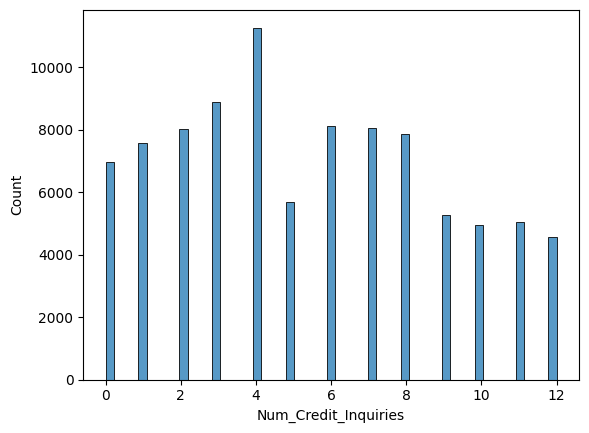

In [84]:
import seaborn as sns

_ = sns.histplot(
    df_train_clean[
        df_train_clean["Num_Credit_Inquiries"]
        < df_train_clean["Num_Credit_Inquiries"].quantile(0.95)
    ],
    x="Num_Credit_Inquiries",
)

In [85]:
df_train_clean[
    df_train_clean["Num_Credit_Inquiries"]
    < df_train_clean["Num_Credit_Inquiries"].quantile(0.95)
]["Num_Credit_Inquiries"].describe()

count   92,318.00
mean         5.41
std          3.49
min          0.00
25%          3.00
50%          5.00
75%          8.00
max         12.00
Name: Num_Credit_Inquiries, dtype: float64

In [86]:
df_train_clean["Credit_Score"].value_counts(normalize=True)

Credit_Score
Standard   0.53
Poor       0.29
Good       0.18
Name: proportion, dtype: float64

In [87]:
df_train_clean[
    df_train_clean["Num_Credit_Inquiries"]
    > df_train_clean["Num_Credit_Inquiries"].quantile(0.95)
]["Credit_Score"].value_counts(normalize=True)

Credit_Score
Poor       0.49
Standard   0.43
Good       0.08
Name: proportion, dtype: float64

In [88]:
df_train_clean["Num_Credit_Inquiries"] = df_train_clean["Num_Credit_Inquiries"].clip(
    upper=df_train_clean["Num_Credit_Inquiries"].quantile(0.95)
)
df_train_clean["Num_Credit_Inquiries"].describe()

count   98,035.00
mean         5.85
std          3.83
min          0.00
25%          3.00
50%          6.00
75%          9.00
max         13.00
Name: Num_Credit_Inquiries, dtype: float64

In [89]:
df_train_clean["Num_Credit_Inquiries"] = df_train_clean["Num_Credit_Inquiries"].fillna(
    df_train_clean["Num_Credit_Inquiries"].mean()
)
df_train_clean["Num_Credit_Inquiries"].isnull().sum()

np.int64(0)

In [90]:
df_train_clean["Num_Credit_Inquiries"].describe()

count   100,000.00
mean          5.85
std           3.79
min           0.00
25%           3.00
50%           5.85
75%           9.00
max          13.00
Name: Num_Credit_Inquiries, dtype: float64

In [91]:
missing = pd.DataFrame(
    {
        "missing_count": df_train_clean.isna().sum(),
        "missing_pct": df_train_clean.isna().mean() * 100,
    }
)

missing = missing.sort_values("missing_pct", ascending=False)

missing.head(10)

,missing_count,missing_pct
Customer_ID,0,0.00
Num_of_Delayed_Payment,0,0.00
Credit_Score,0,0.00
Home Equity Loan,0,0.00
Mortgage Loan,0,0.00
Student Loan,0,0.00
Credit-Builder Loan,0,0.00
Personal Loan,0,0.00
Auto Loan,0,0.00
Payday Loan,0,0.00


# Export

In [98]:
df_train_clean.columns
df_train_clean = df_train_clean.drop(columns=["mhs_missing"])

In [100]:
df_train_clean["Credit_Score"].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

In [101]:
df_train_clean["Credit_Score_binomial"] = df_train_clean["Credit_Score"].map(
    {"Standard": 0, "Poor": 1, "Good": 0}
)
df_train_clean = df_train_clean.drop(columns=["Credit_Score"])

In [102]:
df_train_clean.to_csv("data/df_cleaned.csv", index=False)